# Exploratory Data Analysis — Credit Card Fraud Detection

**Guideline Coverage:**
- Perform EDA to understand data characteristics, identify patterns, and detect potential issues
- Calculate statistical baselines (mean, variance, distribution) for drift detection
- Document data sources, formats, and potential biases

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [4]:
import sys
sys.path.append('..')

from src.data.ingest import load_config, load_raw_data
from src.data.validate import run_all_validations

config = load_config('../configs/config.yaml')
df = load_raw_data('../' + config['data']['raw_path'])

print(f'Shape: {df.shape}')
df.head()

INFO:src.data.ingest:Loading raw data from ../data/raw/creditcard.csv
INFO:src.data.ingest:Loaded 284807 rows and 31 columns


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Basic Statistics

In [5]:
print('=== Dataset Info ===')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'\nData types:')
print(df.dtypes.value_counts())

=== Dataset Info ===
Rows: 284,807
Columns: 31
Missing values: 0
Duplicates: 1081

Data types:
float64    30
int64       1
Name: count, dtype: int64


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Class Distribution (Imbalance Analysis)

Class Distribution:
  Legitimate (0): 284,315 (99.83%)
  Fraud (1):      492 (0.173%)
  Imbalance ratio: 1:577


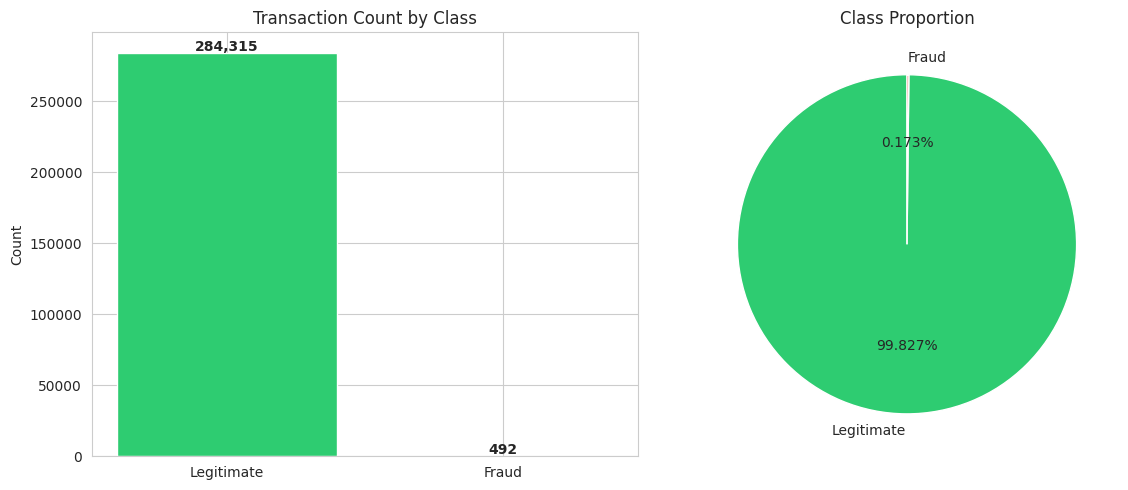

In [7]:
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(f'  Legitimate (0): {fraud_count[0]:,} ({fraud_pct[0]:.2f}%)')
print(f'  Fraud (1):      {fraud_count[1]:,} ({fraud_pct[1]:.3f}%)')
print(f'  Imbalance ratio: 1:{fraud_count[0]//fraud_count[1]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], fraud_count.values, color=colors)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_count.values, labels=['Legitimate', 'Fraud'], 
            autopct='%1.3f%%', colors=colors, startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('../docs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Distributions

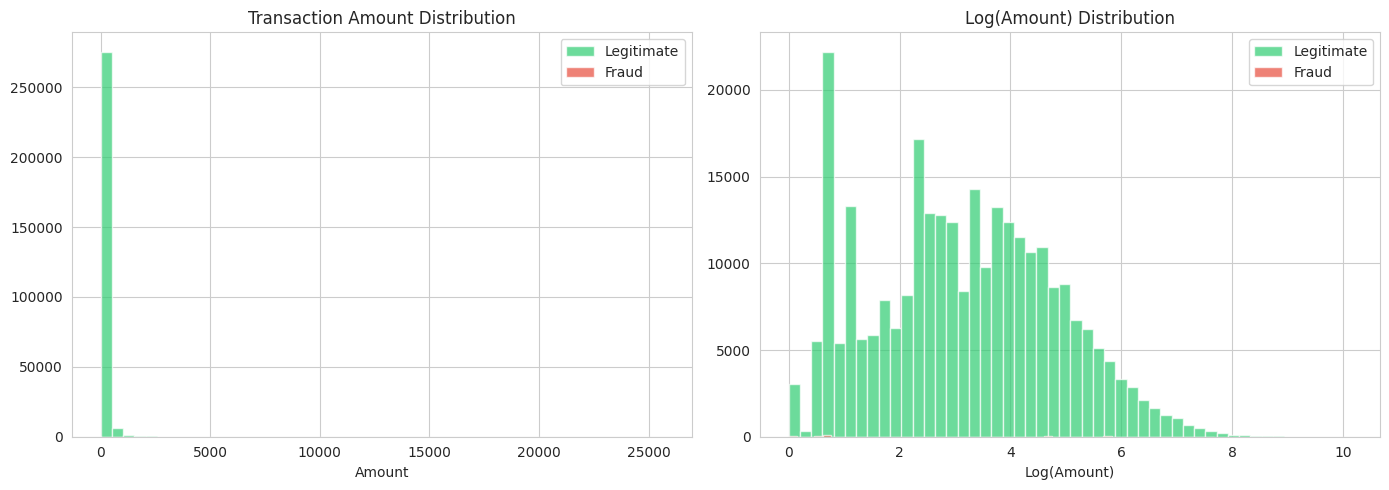

Amount stats - Legit: mean=88.29, median=22.00
Amount stats - Fraud: mean=122.21, median=9.25


In [8]:
# Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Legitimate', color='#2ecc71')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].legend()

# Log-transformed amount
axes[1].hist(np.log1p(df[df['Class']==0]['Amount']), bins=50, alpha=0.7, label='Legitimate', color='#2ecc71')
axes[1].hist(np.log1p(df[df['Class']==1]['Amount']), bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
axes[1].set_title('Log(Amount) Distribution')
axes[1].set_xlabel('Log(Amount)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Amount stats - Legit: mean={df[df["Class"]==0]["Amount"].mean():.2f}, median={df[df["Class"]==0]["Amount"].median():.2f}')
print(f'Amount stats - Fraud: mean={df[df["Class"]==1]["Amount"].mean():.2f}, median={df[df["Class"]==1]["Amount"].median():.2f}')

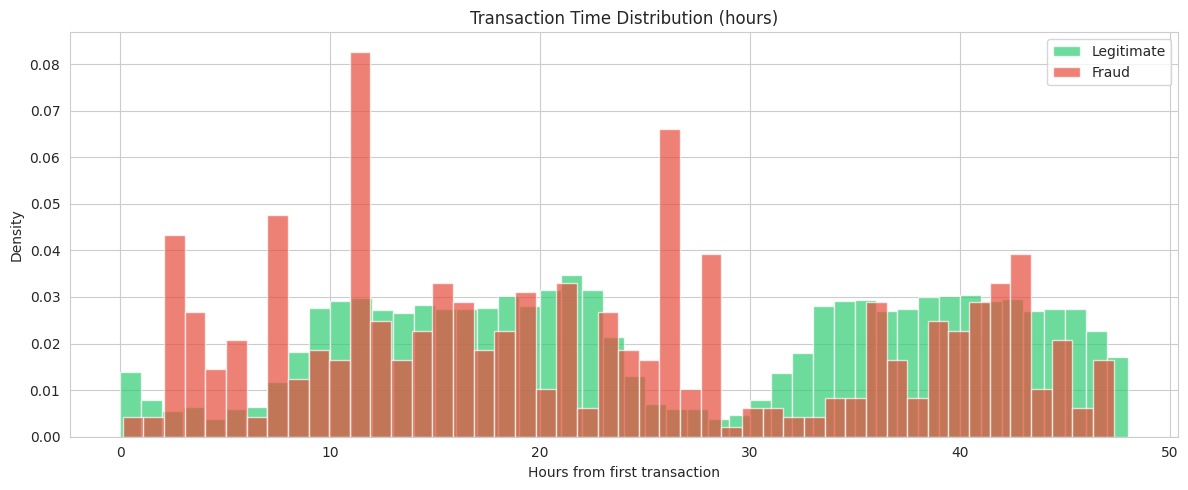

In [9]:
# Time distribution
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.7, label='Legitimate', color='#2ecc71', density=True)
ax.hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.7, label='Fraud', color='#e74c3c', density=True)
ax.set_title('Transaction Time Distribution (hours)')
ax.set_xlabel('Hours from first transaction')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('../docs/time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Top discriminative features: ['V3', 'V14', 'V17', 'V12', 'V10', 'V7']


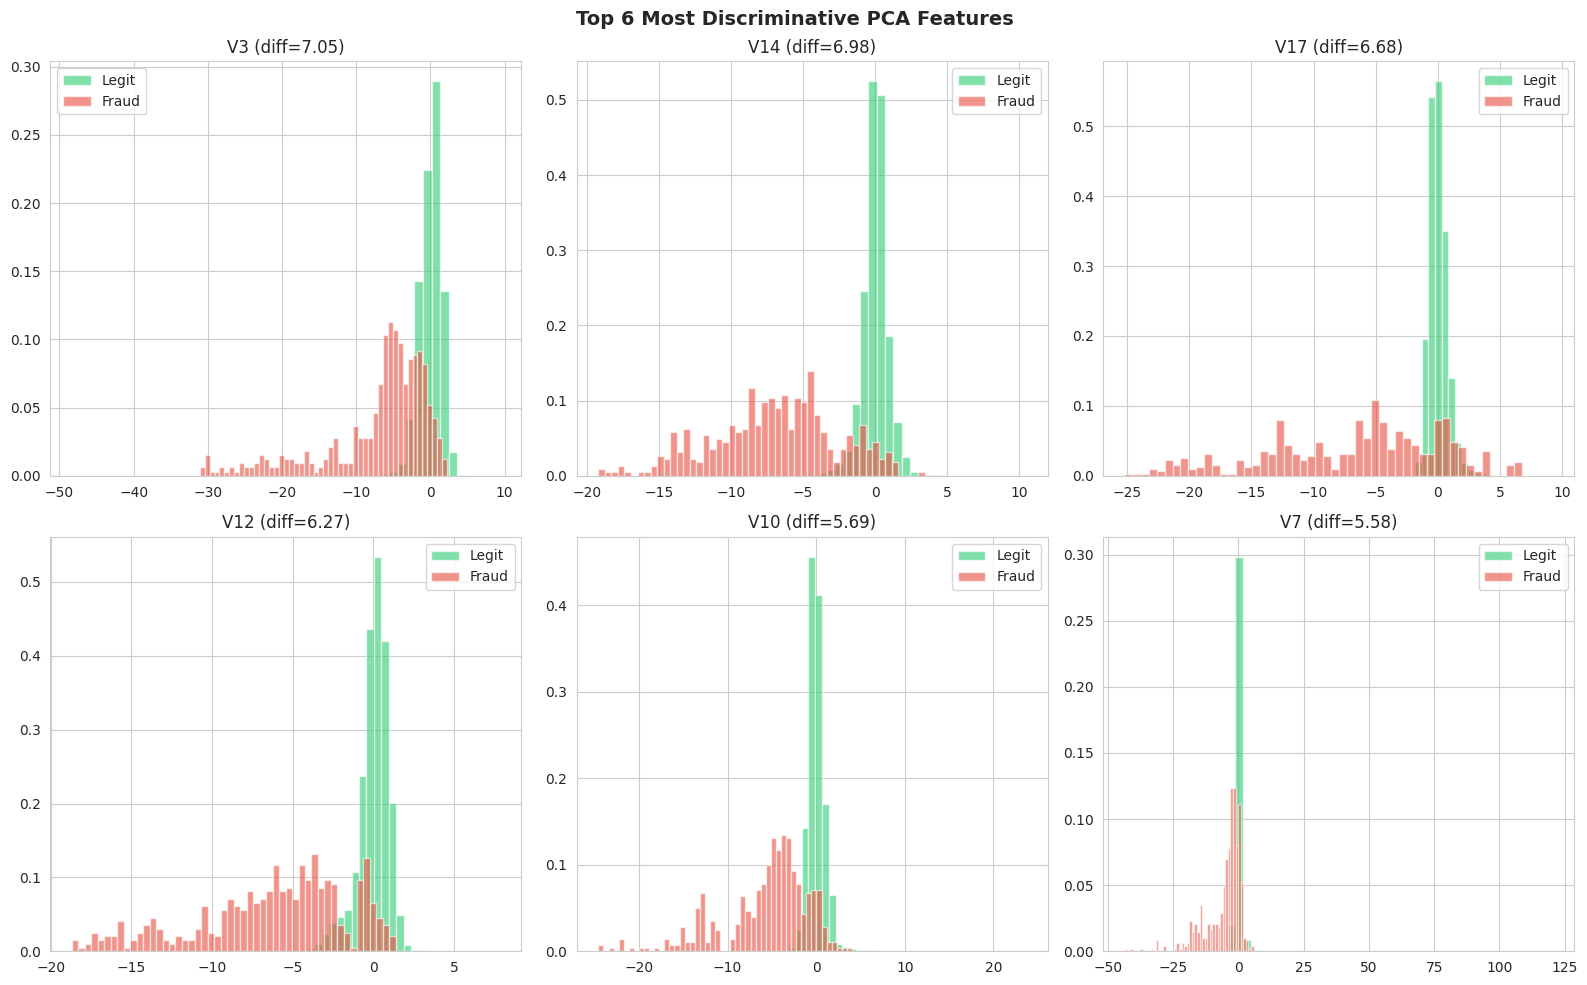

In [10]:
# V-feature distributions: show top features that differ most between fraud/legit
v_cols = [f'V{i}' for i in range(1, 29)]

# Calculate mean difference between fraud and legit for each V feature
mean_diff = {}
for col in v_cols:
    legit_mean = df[df['Class']==0][col].mean()
    fraud_mean = df[df['Class']==1][col].mean()
    mean_diff[col] = abs(fraud_mean - legit_mean)

# Top 6 most discriminative features
top_features = sorted(mean_diff, key=mean_diff.get, reverse=True)[:6]
print(f'Top discriminative features: {top_features}')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, feat in enumerate(top_features):
    ax = axes[idx//3][idx%3]
    ax.hist(df[df['Class']==0][feat], bins=50, alpha=0.6, label='Legit', color='#2ecc71', density=True)
    ax.hist(df[df['Class']==1][feat], bins=50, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
    ax.set_title(f'{feat} (diff={mean_diff[feat]:.2f})')
    ax.legend()

plt.suptitle('Top 6 Most Discriminative PCA Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

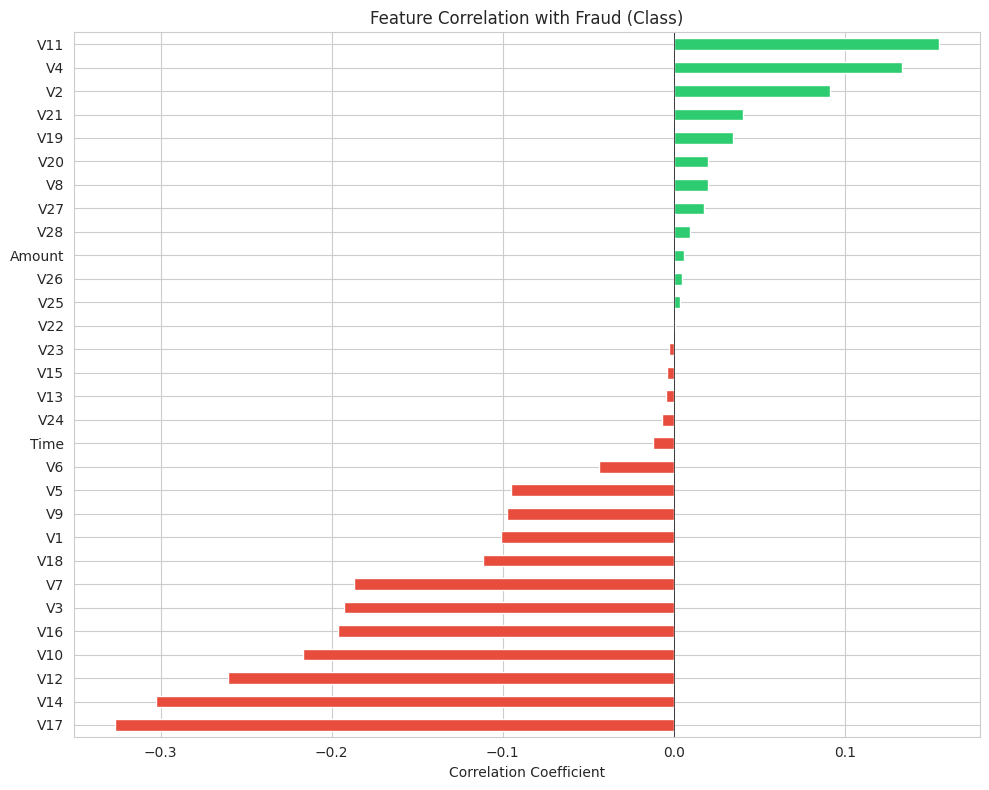


Top positive correlations with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top negative correlations with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [11]:
# Correlation with target
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.values]
correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Feature Correlation with Fraud (Class)')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../docs/correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop positive correlations with fraud:')
print(correlations.tail(5))
print('\nTop negative correlations with fraud:')
print(correlations.head(5))

## 6. Outlier Detection

Amount Outliers: 31,904 (11.20%)
  Q1=5.60, Q3=77.16, IQR=71.56
  Lower bound: -101.75
  Upper bound: 184.51
  Max amount: 25691.16


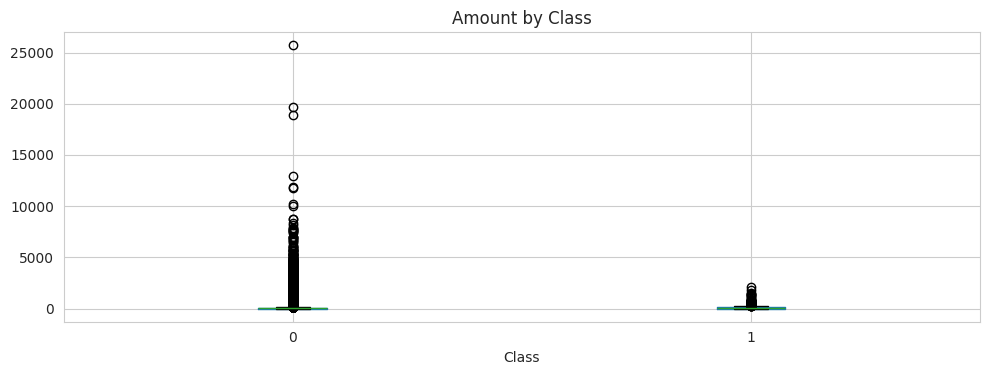

In [12]:
# Check outliers in Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df['Amount'] < Q1 - 1.5*IQR) | (df['Amount'] > Q3 + 1.5*IQR)

print(f'Amount Outliers: {outlier_mask.sum():,} ({outlier_mask.mean()*100:.2f}%)')
print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'  Lower bound: {Q1 - 1.5*IQR:.2f}')
print(f'  Upper bound: {Q3 + 1.5*IQR:.2f}')
print(f'  Max amount: {df["Amount"].max():.2f}')

# Box plot
fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot(column='Amount', by='Class', ax=ax)
ax.set_title('Amount by Class')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Compute & Save Drift Baselines

**Guideline:** During EDA, calculate the statistical baseline (mean, variance, distribution) of features for drift detection.

In [13]:
from src.features.feature_engineering import compute_drift_baselines

# Compute baselines on the feature columns (excluding target)
feature_df = df.drop(columns=['Class'])
baselines = compute_drift_baselines(feature_df, '../data/baselines/')

# Show a sample
print(f'Baselines saved for {len(baselines)} features')
print(f'\nExample — Amount baseline:')
for k, v in baselines['Amount'].items():
    print(f'  {k}: {v:.4f}')

INFO:src.features.feature_engineering:Computing drift baselines...
INFO:src.features.feature_engineering:Saved baselines for 30 features to ../data/baselines/feature_baselines.json


Baselines saved for 30 features

Example — Amount baseline:
  mean: 88.3496
  std: 250.1201
  variance: 62560.0690
  min: 0.0000
  max: 25691.1600
  median: 22.0000
  q25: 5.6000
  q75: 77.1650


## 8. Key EDA Findings Summary

| Finding | Detail |
|---------|--------|
| Dataset size | 284,807 transactions |
| Class imbalance | ~0.17% fraud (highly imbalanced) |
| Missing values | None |
| Features | 28 PCA components (V1-V28) + Time + Amount |
| Fraud amounts | Tend to be smaller than average |
| Top discriminative features | V14, V12, V10 show strongest separation |
| Action items | Use scale_pos_weight in XGBoost, use PR-AUC as primary metric |